# Parecer de churn: o que a controladoria registrou e o CS não explicou, e vice-versa

Duas bases sobre o mesmo fenômeno:

- **Controladoria** (`Churn e Retração - Produtor Rural (1).xlsx`): o churn que entrou no MRR, por competência, uma linha por contrato e produto.
- **Relatório de churn do CS** (`relatorio-churn-2026-09-30.xlsx`): o parecer que o CSM preenche quando o cliente pede o cancelamento (motivo, abordagem, sistema de destino, NPS).

Queremos saber: (1) quais churns da controladoria ainda não têm parecer do CS; (2) quais pareceres não aparecem na controladoria; (3) nos casos que estão nas duas, onde as informações divergem.

Critério combinado: **só churn precisa de parecer**. Downsell (retração) entra apenas como informação.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings

warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")
pd.set_option("display.max_columns", None)
pd.set_option("display.max_colwidth", 60)

In [2]:
COR_PRIMARIA   = "#0072B2"
COR_SECUNDARIA = "#94A3B8"
COR_DESTAQUE   = "#E69F00"
PALETA = ["#0072B2", "#E69F00", "#009E73", "#CC79A7", "#56B4E9", "#D55E00"]

plt.rcParams.update({
    "figure.figsize": (10, 6),
    "figure.dpi": 110,
    "font.size": 12,
    "axes.titlesize": 15,
    "axes.titleweight": "bold",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "axes.prop_cycle": plt.cycler(color=PALETA),
})

def reais(v):
    return f"R$ {v:,.2f}".replace(",", "X").replace(".", ",").replace("X", ".")

## As duas bases foram lidas corretamente?

In [3]:
ctrl = pd.read_excel("Churn e Retração - Produtor Rural (1).xlsx")
cs = pd.read_excel("relatorio-churn-2026-09-30.xlsx")
carteira = pd.read_excel("../../projetos/clientes-alto-volume-tickets/dados/Lista de Clientes.xlsx")
ctrl.shape, cs.shape, carteira.shape

((65, 14), (31, 31), (796, 18))

In [4]:
ctrl.head(3)

,Vertical,Grupo,Clientes_Ativos,CONTRATO,Novo_Produto,valor,Variacao,competencia,Cod_Cliente,Churn/Downsell,Tipo,Motivo,Categoria,Obs
0,Produtor Rural,ACASSIO TELES DE CASTRO,ACASSIO TELES DE CASTRO,30005439,My Farm ERP,0.00,-1200.00,2026-01-01,30017239.0,Churn,Total,Falta de mão de obra/estrutura do cliente,Negócio do Cliente,NaN
1,Produtor Rural,ADEMIR JOSE COMPARIM IE,ADEMIR JOSE COMPARIM IE-28.523.221-5,30002927,My Farm ERP,0.00,-840.51,2026-01-01,30012242.0,Churn,Total,Motivo não identificado / não informado,Não Identificado,"Não localizado historico CS, apenas informação do time d..."
2,Produtor Rural,CAPIVARY,CAPIVARY AGROPASTORIL LTDA,30002051,Agrimanager ERP,-1657.47,-1657.47,2026-01-01,30010978.0,Downsell,Downsell,Substituição por solução do contador/parceiro,Concorrência / Substituição Tecnológica,NaN


In [5]:
cs.head(3)

,Status,Data solicitação,Código SD,Cliente,Cidade,UF,Grupo econômico,MMR,Curva,Tamanho cliente,Tipo cancelamento,Produtos cancelados,Motivo churn cliente,Motivo churn cliente outro,Cliente engajado,Motivo churn interno,Motivo churn interno outro,Sistema migração,NPS,Data assinatura contrato,Data última RTR,Histórico motivo cancelamento,Detalhamento abordagem,Tarefa vinculada,Criado em,Criado por,Atualizado em,Atualizado por,Arquivado em,Arquivado por,Motivo arquivamento
0,Ativo,03/09/2026,30011104,LISEU JOSE SCHERER - IE.13.260.772-7,SAPEZAL,MT,30000094,954.44,B,De 1.001 até 5.000 hectares,Total,MYFARM,Outro,"A CLIENTE NÃO RELATOU INSATISFAÇÃO COM O MYFARM, FALTA D...",Não,Falta de engajamento do cliente nas ações de CS,NaN,UNISYSTEM COMPASS,10,19/10/2020,18/05/2026,O cliente liseu jose scherer possui histórico de relacio...,"Em 31/08/2026, foi realizada abordagem pela CSM responsá...",d54bf568-b232-4cdf-adaa-1427e63b3708,"24/09/2026, 09:35",ANA FLAVIA ROCHA,"24/09/2026, 09:35",—,NaN,—,NaN
1,Ativo,03/09/2026,30010801,ARLINDO FIORAVANTE CAETANO BELLINCANTA IE: 13.388.304-3,SINOP,MT,30000651,3623.68,C,De 1.001 até 5.000 hectares,Total,"SIAGRI AGRIMANAGER, AGM",Outro,DIFICULDADE FINANCEIRA,Não,Outro,DIFICULDADE FINANCEIRA E DIFICULDADE TÉCNICAS COM A RESO...,NÃO INFORMADO,6,27/03/2024,03/09/2026,A cliente danúbia de paula tomazini solicitou a análise ...,"Diante da situação apresentada pela cliente, foi encamin...",fa31ff0b-0f93-4bef-aa2c-0f91a6ebd2f5,"29/09/2026, 18:01",GIOVANNA ALICE FERREIRA DA COSTA,"29/09/2026, 18:01",—,NaN,—,NaN
2,Ativo,22/08/2026,30017911,MARCO ANTONIO ZUFFELLATO,IPAMERI,GO,30001159,1200.83,C,De 1.001 até 5.000 hectares,Total,MYFARM,Falta de Funcionalidades Essenciais,NaN,Sim,Venda com baixa aderência,NaN,NÃO CONFIRMADO,5,28/06/2025,19/01/2026,O cliente contratou o myFarm com a expectativa de profis...,Foram realizados diagnóstico técnico e documentação das ...,a896e011-5e0e-4c93-8770-c470fba2a872,"31/08/2026, 11:08",ANA FLAVIA ROCHA,"31/08/2026, 11:08",—,NaN,—,NaN


**Leitura:** as três bases abriram limpas: acentos legíveis, valores numéricos, datas do CS ainda como texto (convertidas abaixo). A controladoria tem uma linha por contrato e produto, então o mesmo cliente pode aparecer mais de uma vez. A carteira de clientes (`Lista de Clientes.xlsx`) entra só para trazer o CSM responsável de cada contrato.

## Como ligar as duas bases?
A chave natural é o código do cliente: `Cod_Cliente` na controladoria e `Código SD` no CS. Duas linhas da controladoria vieram sem código; tentamos recuperar pelo número do contrato na carteira.

In [6]:
ctrl["contrato"] = ctrl["CONTRATO"].astype(str).str.split("-").str[0].astype(int)
carteira["contrato"] = pd.to_numeric(carteira["CONTRATO"], errors="coerce")
carteira["cod"] = pd.to_numeric(carteira["COD_CLIENTE"], errors="coerce")
mapa_contrato = carteira.dropna(subset=["contrato"]).drop_duplicates("contrato").set_index("contrato")
ctrl["cod"] = ctrl["Cod_Cliente"].fillna(ctrl["contrato"].map(mapa_contrato["cod"]))
ctrl.loc[ctrl["Cod_Cliente"].isna(), ["Clientes_Ativos", "contrato", "cod"]]

,Clientes_Ativos,contrato,cod
38,GUILHERME DE ARAUJO PREDIGER,30007398,30021139.0
64,JERLUCIO FERNANDES DE OLIVEIRA - BOM JESUS DE GOIAS-GO,30006214,30015631.0


Os dois códigos faltantes foram recuperados pelo contrato. Agora trazemos o CSM de cada contrato (pela carteira) e convertemos as datas do CS.

In [7]:
mapa_cod = carteira.dropna(subset=["cod"]).drop_duplicates("cod").set_index("cod")
ctrl["csm"] = ctrl["contrato"].map(mapa_contrato["AGENTE_RELACIONAMENTO"]).fillna(ctrl["cod"].map(mapa_cod["AGENTE_RELACIONAMENTO"]))
ctrl["cod"] = ctrl["cod"].astype(int)
cs["cod"] = cs["Código SD"]
cs["data_solicitacao"] = pd.to_datetime(cs["Data solicitação"], dayfirst=True)
cs["data_criacao"] = pd.to_datetime(cs["Criado em"], format="%d/%m/%Y, %H:%M")
ctrl[["Clientes_Ativos", "cod", "csm"]].sample(4, random_state=1), ctrl["csm"].isna().sum()

(                               Clientes_Ativos       cod  \
 51          CLEONESIO LUIZ MARX IE 15.738454-3  30011918   
 55  JOSE ARNALDO DE CASTRO NETTO IE 11511041-0  30011822   
 46               VALDIR FREIER  IE 00132823500  30011963   
 2                   CAPIVARY AGROPASTORIL LTDA  30010978   
 
                           csm  
 51      RAMONA GOMES DE BRITO  
 55      RAMONA GOMES DE BRITO  
 46                        NaN  
 2   ISABELLA CLARINDO PAULINO  ,
 np.int64(13))

In [8]:
cs[["Cliente", "data_solicitacao", "data_criacao"]].head(3)

,Cliente,data_solicitacao,data_criacao
0,LISEU JOSE SCHERER - IE.13.260.772-7,2026-09-03,2026-09-24 09:35:00
1,ARLINDO FIORAVANTE CAETANO BELLINCANTA IE: 13.388.304-3,2026-09-03,2026-09-29 18:01:00
2,MARCO ANTONIO ZUFFELLATO,2026-08-22,2026-08-31 11:08:00


Datas convertidas. Treze linhas da controladoria ficaram sem CSM: vamos ver adiante se isso atinge os churns que precisam de parecer.

## Quanto do que a controladoria registrou é churn e quanto é downsell?
Só o churn exige parecer, então primeiro separamos o universo. Contamos clientes (não linhas), já que um cliente pode perder mais de um produto.

In [9]:
resumo = ctrl.groupby("Churn/Downsell").agg(linhas=("cod", "size"), clientes=("cod", "nunique"), mrr_perdido=("Variacao", "sum"))
resumo.assign(mrr_perdido=resumo["mrr_perdido"].map(reais))

,linhas,clientes,mrr_perdido
Churn/Downsell,,,
Churn,50,48,"R$ -73.705,24"
Downsell,15,13,"R$ -50.838,24"


In [10]:
por_mes = ctrl.pivot_table(index=ctrl["competencia"].dt.strftime("%Y-%m"), columns="Churn/Downsell", values="cod", aggfunc="nunique", fill_value=0)
por_mes

Churn/Downsell,Churn,Downsell
competencia,,
2026-01,5,1
2026-02,8,4
2026-03,3,1
2026-05,7,3
2026-06,12,3
2026-07,6,2
2026-08,7,0


**Resultado:** o universo que precisa de parecer são **48 clientes com churn**, de janeiro a agosto. O downsell (13 clientes) pesa bastante no MRR, porque são clientes grandes reduzindo produto, mas fica fora da cobrança. Chama atenção que **abril não tem nenhum registro** na controladoria: ou não houve churn no mês (improvável, com 12 em junho), ou a competência de abril não foi lançada na planilha.

## Quantos churns da controladoria já têm parecer do CS?
Primeiro pelo código do cliente, que é a ligação mais segura.

In [11]:
churn = ctrl[ctrl["Churn/Downsell"] == "Churn"]
churn_cli = churn.groupby("cod").agg(cliente=("Clientes_Ativos", "first"), grupo=("Grupo", "first"), competencia=("competencia", "min"), produtos=("Novo_Produto", lambda s: ", ".join(sorted(set(s)))), mrr_perdido=("Variacao", "sum"), motivo_ctrl=("Motivo", "first"), categoria_ctrl=("Categoria", "first"), csm=("csm", "first")).reset_index()
churn_cli["tem_parecer"] = churn_cli["cod"].isin(cs["cod"])
churn_cli["tem_parecer"].value_counts().to_frame()

,count
tem_parecer,
False,26
True,22


Antes de aceitar o número: algum parecer sem par pode ser o mesmo cliente cadastrado com outro código (fazenda x produtor, empresa do grupo). Comparamos os nomes dos pareceres sem par com todos os nomes da controladoria, e também o grupo econômico.

In [12]:
from rapidfuzz import process, fuzz

sem_par = cs[~cs["cod"].isin(ctrl["cod"])]
nomes_ctrl = (ctrl["Clientes_Ativos"] + " | " + ctrl["Grupo"]).tolist()
sugestao = sem_par["Cliente"].apply(lambda n: process.extractOne(n, nomes_ctrl, scorer=fuzz.token_set_ratio))
sem_par.assign(parecido=sugestao.str[0].str[:45], nota=sugestao.str[1].round())[["cod", "Cliente", "data_solicitacao", "Grupo econômico", "parecido", "nota"]]

,cod,Cliente,data_solicitacao,Grupo econômico,parecido,nota
0,30011104,LISEU JOSE SCHERER - IE.13.260.772-7,2026-09-03,30000094,RODRIGO KONAGESKI I.E.13.252.476-7 | FAZENDAS,48.0
1,30010801,ARLINDO FIORAVANTE CAETANO BELLINCANTA IE: 13.388.304-3,2026-09-03,30000651,RICARDO SILVA ROCHA IE: 11.196.197-1 | SEGMEN,49.0
3,30020569,FERNANDO VIEIRA PERES,2026-08-14,30001389,CARLOS FERNANDO DA SILVEIRA BUENO | CARLOS FE,64.0
9,30012735,GEMIRO CARAFINI IE: 11.106.270-5,2026-06-10,30000346,CELSO LEAO RIBEIRO | IE 11.301.206-3 | CELSO,53.0
12,30015685,IVAN ALVES SILVA,2026-06-01,30000830,MARIO PINTO DA SILVA | MARIO PINTO DA SILVA,53.0
13,30020548,AGRO ALIANCA LTDA,2026-05-28,30001383,AGRO 100 COMERCIO DE PRODUTOS AGRICOLAS LTDA,69.0
17,30013597,LUCIVAL PORTILHO ARANTES IE 29.474.545-9,2026-05-23,30000742,CLEONESIO LUIZ MARX IE 15.738454-3 | CLEONESI,50.0
27,30017941,AUGUSTO CESAR ANDRADE MAIA,2026-04-08,30001186,MARCELO ANDRE KONAGESKI | MARCELO ANDRE KONAG,51.0


**Resultado:** nenhum nome parecido de verdade (as notas de semelhança ficam abaixo de 70, e os pares sugeridos são pessoas diferentes). Então a ligação por código está certa: **22 churns com parecer e 26 sem**. E **8 pareceres do CS não aparecem em nenhuma linha da controladoria**, nem como churn nem como downsell.

## Por que esses 8 pareceres não estão na controladoria?
Hipóteses: o cancelamento ainda não virou competência (pedido recente), o cliente foi retido, ou o contrato ainda está em disputa. A carteira diz a situação atual do contrato.

In [13]:
situacao = carteira.dropna(subset=["cod"]).groupby("cod")["SITUACAO_CONTRATO"].agg(lambda s: ", ".join(sorted(set(s))))
sem_par[["cod", "Cliente", "data_solicitacao", "Tipo cancelamento", "Produtos cancelados", "MMR", "Criado por"]].assign(situacao_hoje=sem_par["cod"].map(situacao)).sort_values("data_solicitacao")

,cod,Cliente,data_solicitacao,Tipo cancelamento,Produtos cancelados,MMR,Criado por,situacao_hoje
27,30017941,AUGUSTO CESAR ANDRADE MAIA,2026-04-08,Total,MYFARM,2542.40,MARIANA AMORIM,SUSPENSO
17,30013597,LUCIVAL PORTILHO ARANTES IE 29.474.545-9,2026-05-23,Total,SIAGRI AGRIMANAGER E ALIARE CLOUD,5896.12,ISABELLA PAULINO,CANCELADO
13,30020548,AGRO ALIANCA LTDA,2026-05-28,Total,MYFARM,1950.00,ANDREZZA PERRONI,SUSPENSO
12,30015685,IVAN ALVES SILVA,2026-06-01,Total,MYFARM,1202.27,ANDREZZA PERRONI,SUSPENSO
9,30012735,GEMIRO CARAFINI IE: 11.106.270-5,2026-06-10,Total,SIAGRI AGRIMANAGER,2581.48,MARIANA AMORIM,SUSPENSO
3,30020569,FERNANDO VIEIRA PERES,2026-08-14,Total,MYFARM,1670.87,ANDREZZA PERRONI,CANCELADO
0,30011104,LISEU JOSE SCHERER - IE.13.260.772-7,2026-09-03,Total,MYFARM,954.44,ANA FLAVIA ROCHA,CANCELADO
1,30010801,ARLINDO FIORAVANTE CAETANO BELLINCANTA IE: 13.388.304-3,2026-09-03,Total,"SIAGRI AGRIMANAGER, AGM",3623.68,GIOVANNA ALICE FERREIRA DA COSTA,CANCELADO


**Resultado:** os 8 se dividem em dois grupos com explicações diferentes.

- **4 continuam suspensos** na carteira (Augusto, Agro Aliança, Ivan, Gemiro). A controladoria só reconhece churn no cancelamento formal (decisão de 23/09), então é esperado que não estejam lá. [Certo] Mas são pedidos de abril a junho parados há 3 a 5 meses: ou viram cancelamento, ou viram retenção. Hoje ficam no limbo.
- **4 já estão cancelados** na carteira. Três deles (Fernando, Liseu, Arlindo) pediram entre 14/08 e 03/09, e a base da controladoria vai só até agosto, então devem entrar na competência de setembro. [Provável] O caso que não se explica é o **Lucival**: pediu em 23/05, está cancelado e tem o maior MRR da lista, mas não aparece em nenhum mês. É o ponto a levar à controladoria. [Provável: pode ter sido lançado com outro código ou na vertical errada]

## Quais churns da controladoria estão sem parecer, e de quem é cada um?
Esta é a lista de cobrança do CS. Ordenamos por MRR perdido, e o CSM vem da carteira.

In [14]:
faltando = churn_cli[~churn_cli["tem_parecer"]].sort_values("mrr_perdido")
faltando.assign(competencia=faltando["competencia"].dt.strftime("%Y-%m"), mrr_perdido=faltando["mrr_perdido"].map(reais))[["cod", "cliente", "competencia", "produtos", "mrr_perdido", "motivo_ctrl", "csm"]]

,cod,cliente,competencia,produtos,mrr_perdido,motivo_ctrl,csm
5,30007727,3SB PRODUTOS AGRICOLAS S.A.,2026-02,Agrimanager ERP,"R$ -4.170,46",Falta de funcionalidade / aderência,DYENIFER DA SILVA SOARES MANFROI
18,30013024,RICARDO SILVA ROCHA IE: 11.196.197-1,2026-02,Agrimanager ERP,"R$ -3.117,15",Migração entre produtos/soluções da Aliare,AMANDA CRISTINA DA SILVA SANTOS
44,30018439,LUIS HENRIQUE PAZINI E OUTRO - IE - 133440532,2026-05,My Farm ERP,"R$ -2.775,55",Performance / estabilidade insatisfatória,NaN
9,30010916,ZORZETTO ASSES. E CONSULTORIA AGRONOMICA LTDA.,2026-06,Agrimanager ERP,"R$ -2.243,46",Baixa adoção / utilização da plataforma,LUCAS LEVI PARANAGUA PINHEIRO
28,30016155,VALQUIRIA MARCELINO FERREIRA ABREU IE: 13.429.008-9,2026-05,"Agrimanager ERP, Aliare Cloud - PR","R$ -2.110,81",Baixa adoção / utilização da plataforma,NaN
4,30006916,CLODOVEU FRANCIOSI IE 133535746,2026-03,Agrimanager Algodoeira,"R$ -1.926,99",Migração para solução concorrente,ANDREZZA CAMARGO PEREIRA PERRONI
7,30010348,SEMENTES TRES PINHEIROS SEEDS LTDA,2026-01,Aliare Cloud - PR,"R$ -1.875,06",Falta de valor percebido (ROI),RAMONA GOMES DE BRITO
10,30010978,CAPIVARY AGRO PASTORIL - GOIANIA-GO,2026-08,Agrimanager ERP,"R$ -1.847,82",Encerramento das atividades da empresa cliente,ISABELLA CLARINDO PAULINO
2,20000027,CARLOS ALBERTO MORESCO,2026-02,Vistra BI - PR,"R$ -1.655,56",Restrição financeira / redução de custos,GIOVANNA ALICE FERREIRA DA COSTA
1,10001146,AGRO 100 COMERCIO DE PRODUTOS AGRICOLAS LTDA - EM RECUPE...,2026-03,Agrimanager ERP,"R$ -1.375,16",Restrição financeira / redução de custos,LUCAS LEVI PARANAGUA PINHEIRO


**Resultado:** a lista mistura dois problemas. O primeiro é de **responsável**: 8 dos 26 não têm CSM na carteira, e vários dos nomes que aparecem não estão no time de CS atual (Amanda, Andrezza, Ana, Ramona, Giovanna). Isso quer dizer que parte dos pareceres terá de ser reconstruída por quem herdou a carteira. O segundo é de **época**: muitos churns são de janeiro a março. Vale ver se o relatório de churn atual ainda não existia nesses meses.

## A falta de parecer é concentrada nos primeiros meses do ano?
Cobertura de parecer por competência, com o número de churns do mês ao lado, e a data do primeiro parecer criado.

In [15]:
cobertura = churn_cli.groupby(churn_cli["competencia"].dt.strftime("%Y-%m")).agg(churns=("cod", "size"), com_parecer=("tem_parecer", "sum"))
cobertura["cobertura_%"] = (100 * cobertura["com_parecer"] / cobertura["churns"]).round()
cobertura, cs["data_criacao"].min(), cs["data_criacao"].dt.strftime("%Y-%m").value_counts().sort_index().to_dict()

(             churns  com_parecer  cobertura_%
 competencia                                  
 2026-01           5            0          0.0
 2026-02           8            1         12.0
 2026-03           3            0          0.0
 2026-05           7            4         57.0
 2026-06          12            7         58.0
 2026-07           6            5         83.0
 2026-08           7            5         71.0,
 Timestamp('2026-05-20 13:40:00'),
 {'2026-05': 1, '2026-06': 11, '2026-07': 7, '2026-08': 9, '2026-09': 3})

**Resultado:** a falta de parecer tem duas naturezas diferentes. O primeiro parecer do **relatório atual** foi criado em **20/05/2026**, e os churns de janeiro a março são anteriores a ele, com cobertura quase nula (1 caso). De maio em diante o relatório já existia, e mesmo assim cerca de **1 em cada 3 churns ficou sem parecer**: é **falha de processo**, e é o grupo a cobrar primeiro. Os meses têm entre 6 e 12 churns, então a diferença entre julho e agosto é ruído; o que vale é o corte antes e depois de maio.

> **Correção posterior:** antes do relatório atual o CS usava um formulário, e parte dos pareceres de janeiro a março está nele. Ver a seção "Os churns sem parecer estão no formulário antigo?".

Marcamos essa separação na lista de pendências.

In [16]:
inicio_relatorio = cs["data_criacao"].min().normalize()
churn_cli["grupo_pendencia"] = "com parecer"
churn_cli.loc[~churn_cli["tem_parecer"] & (churn_cli["competencia"] < inicio_relatorio.replace(day=1)), "grupo_pendencia"] = "antes do relatório atual (20/05)"
churn_cli.loc[~churn_cli["tem_parecer"] & (churn_cli["competencia"] >= inicio_relatorio.replace(day=1)), "grupo_pendencia"] = "depois do relatório atual (20/05)"
churn_cli.groupby("grupo_pendencia").agg(clientes=("cod", "size"), mrr_perdido=("mrr_perdido", "sum")).assign(mrr_perdido=lambda t: t["mrr_perdido"].map(reais))

,clientes,mrr_perdido
grupo_pendencia,,
antes do relatório atual (20/05),15,"R$ -20.446,48"
com parecer,22,"R$ -38.406,80"
depois do relatório atual (20/05),11,"R$ -14.851,96"


## Nos casos que estão nas duas bases, as informações batem?
Juntamos cada parecer ao registro da controladoria (churn ou downsell) e comparamos quatro coisas: o tipo (total x parcial x downsell), o mês, o valor e o motivo.

In [17]:
ctrl_cli = ctrl.groupby("cod").agg(tipo_ctrl=("Churn/Downsell", lambda s: ", ".join(sorted(set(s)))), competencia=("competencia", "min"), produtos_ctrl=("Novo_Produto", lambda s: ", ".join(sorted(set(s)))), mrr_ctrl=("Variacao", "sum"), motivo_ctrl=("Motivo", "first"), categoria_ctrl=("Categoria", "first")).reset_index()
ambos = cs.merge(ctrl_cli, on="cod", how="inner")
ambos["meses_ate_competencia"] = (ambos["competencia"].dt.to_period("M") - ambos["data_solicitacao"].dt.to_period("M")).apply(lambda p: p.n)
ambos["dif_mrr"] = ambos["MMR"] + ambos["mrr_ctrl"]
len(ambos), ambos[["Tipo cancelamento", "tipo_ctrl"]].value_counts().to_frame()

(23,
                              count
 Tipo cancelamento tipo_ctrl       
 Total             Churn         21
 Parcial           Downsell       1
                   Churn          1)

**Resultado:** o tipo bate em 22 dos 23. A exceção é um cancelamento que o CS marcou como **parcial** e a controladoria lançou como **churn** (detalhado abaixo).

## Quanto tempo passa entre o pedido do cliente e a competência do churn?
Se o intervalo for longo ou negativo, o parecer e a controladoria estão falando de momentos diferentes.

In [18]:
ambos["meses_ate_competencia"].value_counts().sort_index().to_frame()

,count
meses_ate_competencia,
0,10
1,6
2,3
3,3
4,1


In [19]:
ambos.loc[(ambos["meses_ate_competencia"] < 0) | (ambos["meses_ate_competencia"] > 2) | (ambos["tipo_ctrl"] != "Churn") | (ambos["Tipo cancelamento"] != "Total"), ["Cliente", "data_solicitacao", "competencia", "meses_ate_competencia", "Tipo cancelamento", "tipo_ctrl", "Produtos cancelados", "produtos_ctrl"]]

,Cliente,data_solicitacao,competencia,meses_ate_competencia,Tipo cancelamento,tipo_ctrl,Produtos cancelados,produtos_ctrl
9,CELSO MANICA E OUTRO(S) IE: 001198301.00-30,2026-05-28,2026-08-01,3,Total,Churn,"SIAGRI AGRIMANAGER, AGM",Agrimanager ERP
12,EDGAR GOMES FILHO,2026-05-22,2026-08-01,3,Total,Churn,MYFARM,My Farm ERP
16,LEONARDO LUIZ OSS,2026-05-14,2026-05-01,0,Parcial,Downsell,BPO FINANCEIRO,My Farm ERP
19,AGROPECUARIA ESTRELA DA MANHA LTDA,2026-04-27,2026-07-01,3,Parcial,Churn,"SIAGRI AGRIMANAGER, AGM",Agrimanager ERP
21,CLEONESIO LUIZ MARX IE 15.738454-3,2026-03-08,2026-07-01,4,Total,Churn,MYFARM,My Farm ERP


**Resultado:** em 19 dos 23 casos o churn entra na competência do próprio mês do pedido ou até dois meses depois, o que é compatível com aviso prévio e fechamento de fatura. Há três pontos a conferir:

- **4 casos com 3 a 4 meses de intervalo** (Celso Manica, Edgar Gomes, Estrela da Manhã, Cleonesio). Nesse tempo o cliente provavelmente continuou faturando ou ficou suspenso. [Provável] Vale confirmar com a controladoria se houve faturamento no intervalo.
- **Leonardo Luiz Oss**: o CS registrou o cancelamento do **BPO Financeiro**, e a controladoria lançou downsell no **My Farm ERP**. Pode ser só o BPO faturado dentro do contrato myFarm, mas o produto precisa ficar igual nas duas bases.
- **Estrela da Manhã**: o CS diz **parcial**, e a controladoria lançou **churn** do AgriManager. Se o cliente manteve algum produto, o certo seria downsell, ou "churn operacional" pela regra de 23/09. Precisa de uma definição única.

## O valor do parecer bate com o MRR perdido na controladoria?
O parecer traz o MRR do cliente; a controladoria, a variação lançada. Diferença acima de 5% entra na lista.

In [20]:
ambos["dif_%"] = (100 * ambos["dif_mrr"] / ambos["MMR"]).round()
(ambos["dif_%"].abs() > 5).value_counts().to_frame()

,count
dif_%,
False,21
True,2


In [21]:
dif_valor = ambos.loc[ambos["dif_%"].abs() > 5, ["Cliente", "Tipo cancelamento", "tipo_ctrl", "MMR", "mrr_ctrl", "dif_mrr", "dif_%"]].sort_values("dif_mrr", key=abs, ascending=False)
dif_valor

,Cliente,Tipo cancelamento,tipo_ctrl,MMR,mrr_ctrl,dif_mrr,dif_%
16,LEONARDO LUIZ OSS,Parcial,Downsell,1355.74,-4195.79,-2840.05,-209.0
18,BRUNO SANCHES TORO,Total,Churn,4010.69,-5661.05,-1650.36,-41.0


**Resultado:** o valor bate em 21 dos 23. As duas diferenças têm explicação concreta:

- **Bruno Sanches Toro**: a controladoria lançou o AgriManager **e o Aliare Cloud** (`R$ 1.650,36`), e o parecer só cita o AgriManager. [Certo] O parecer está incompleto no produto.
- **Leonardo Luiz Oss**: o parecer fala em `R$ 1.355,74` de BPO, e a controladoria lançou `R$ 4.195,79` de downsell no myFarm. É o mesmo caso do produto divergente. [Certo] Um dos dois lados está errado, e só a controladoria consegue dizer qual.

## O motivo registrado pelo CS é o mesmo que a controladoria usa?
As duas bases usam listas de motivos diferentes, então não dá para comparar texto com texto. Olhamos os pares e procuramos contradição de sentido.

In [22]:
ambos[["Cliente", "Motivo churn cliente", "Motivo churn cliente outro", "motivo_ctrl", "categoria_ctrl"]].assign(**{"Motivo churn cliente outro": ambos["Motivo churn cliente outro"].str[:50]}).sort_values("categoria_ctrl")

,Cliente,Motivo churn cliente,Motivo churn cliente outro,motivo_ctrl,categoria_ctrl
22,ROQUE CASSOL,Outro,"UTILIZAVAM APENAS PARA EMISSÃO DE NOTA E LCPR, POR",Substituição por solução do contador/parceiro,Concorrência / Substituição Tecnológica
9,CELSO MANICA E OUTRO(S) IE: 001198301.00-30,Outro,CLIENTE INFORMOU POR EMAIL QUE ESTAVA USANDO OUTRO,Migração para solução concorrente,Concorrência / Substituição Tecnológica
1,JERLUCIO FERNANDES DE OLIVEIRA,Outro,PESSOAS (QUEM ESTA NA FAZENDA NÃO REPASSA AS INFOR,Baixo engajamento do cliente,Experiência & Adoção
2,JOSE ARNALDO DE CASTRO NETTO IE 11511041-0,Outro,NÃO UTILIZAR O SISTEMA,Baixo engajamento do cliente,Experiência & Adoção
20,CLAUDIO AUGUSTO DINIZ - I.E. 13.235.367-9,Dificuldade de Uso,NaN,Baixa adoção / utilização da plataforma,Experiência & Adoção
19,AGROPECUARIA ESTRELA DA MANHA LTDA,Dificuldade de Uso,NaN,Baixo engajamento do cliente,Experiência & Adoção
6,PAULO RICARDO SANTIN,Dificuldade de Uso,NaN,Baixo engajamento do cliente,Experiência & Adoção
12,EDGAR GOMES FILHO,Dificuldade de Uso,NaN,Baixo engajamento do cliente,Experiência & Adoção
4,DIONATAN DONATO,Diminuição de custos,NaN,Restrição financeira / redução de custos,Financeiro
15,CELSO LEAO RIBEIRO | IE 11.301.206-3,Diminuição de custos,NaN,Restrição financeira / redução de custos,Financeiro


**Leitura dos pares:** a maior parte é compatível, com nomes diferentes para a mesma coisa. Aparece, porém, um padrão de **atribuição trocada**: o CS aponta um problema do lado da Aliare (dificuldade de uso, falta de funcionalidade), e a controladoria registra um motivo do lado do cliente (baixo engajamento, falta de mão de obra). Vamos contar esses casos com uma regra explícita.

In [23]:
lado_aliare_cs = ["Dificuldade de Uso", "Falta de Funcionalidades Essenciais", "Falta de Personalização Solicitado pelo Cliente", "Erros Recorrentes / Instabilidade"]
lado_cliente_ctrl = ["Baixo engajamento do cliente", "Falta de mão de obra/estrutura do cliente"]
ambos["motivo_contraditorio"] = ambos["Motivo churn cliente"].isin(lado_aliare_cs) & ambos["motivo_ctrl"].str.strip().isin(lado_cliente_ctrl)
ambos.loc[ambos["motivo_contraditorio"], ["Cliente", "Motivo churn cliente", "Motivo churn interno", "motivo_ctrl", "Cliente engajado"]]

,Cliente,Motivo churn cliente,Motivo churn interno,motivo_ctrl,Cliente engajado
3,FRAVALE AGROPECUARIA LTDA,Dificuldade de Uso,Confirma o motivo pontuado pelo cliente,Falta de mão de obra/estrutura do cliente,Não
6,PAULO RICARDO SANTIN,Dificuldade de Uso,Baixo uso do sistema por parte do cliente / Engajamento,Baixo engajamento do cliente,Não
8,OCTAVIANO RAYMUNDO CAMARGO SILVA IE:212.059.354.118,Dificuldade de Uso,Falta de mão de obra / Equipe pequena,Falta de mão de obra/estrutura do cliente,Não
11,EVANDRO VILELA BARROS IE 11.331.859-6,Falta de Funcionalidades Essenciais,Baixo uso do sistema por parte do cliente / Engajamento,Falta de mão de obra/estrutura do cliente,Não
12,EDGAR GOMES FILHO,Dificuldade de Uso,Confirma o motivo pontuado pelo cliente,Baixo engajamento do cliente,Não
19,AGROPECUARIA ESTRELA DA MANHA LTDA,Dificuldade de Uso,Baixo uso do sistema por parte do cliente / Engajamento,Baixo engajamento do cliente,Não


**Resultado:** a contradição encolhe quando olhamos o motivo interno do próprio parecer. Em 4 dos 6 casos, o CS também registrou, na visão interna, baixo uso ou falta de equipe. A controladoria usou a visão interna do CS, não a fala do cliente, e as duas estão no parecer. Sobram **2 contradições de fato**: **Fravale** e **Edgar Gomes**. Neles o CS escreveu que confirma o motivo do cliente (dificuldade de uso), e a controladoria registrou motivo do lado do cliente. [Certo] Como a amostra é pequena (23 pareceres), é caso a caso, não tendência. Mas vale combinar qual campo do parecer a controladoria deve usar.

## Os pareceres existentes estão completos o bastante para sustentar a análise?
Um parecer existe, mas pode estar vazio onde importa: sistema de destino não informado, motivo "Outro" sem classificação, sem tarefa vinculada que comprove a abordagem.

In [24]:
destino_vazio = ["NÃO INFORMADO", "NAO INFORMADO", "NÃO INFORMOU", "NÃO CONFIRMADO", "NÃO SABEMOS", "NÃO SINALIZOU", "NÃO FOI INFORMADO NO HISTÓRICO.", "NÃO POSSUO ESSA INFORMAÇÃO", "CONCORRENTE"]
lacunas = pd.DataFrame({
    "sistema de destino não informado": cs["Sistema migração"].str.strip().isin(destino_vazio),
    "motivo do cliente = Outro": cs["Motivo churn cliente"].eq("Outro"),
    "motivo interno = Outro": cs["Motivo churn interno"].eq("Outro"),
    "sem tarefa vinculada": cs["Tarefa vinculada"].isna(),
})
lacunas.sum().to_frame("pareceres").assign(de=len(cs))

,pareceres,de
sistema de destino não informado,15,31
motivo do cliente = Outro,10,31
motivo interno = Outro,3,31
sem tarefa vinculada,15,31


In [25]:
cs["Sistema migração"].value_counts().to_frame()

,count
Sistema migração,
NÃO INFORMADO,6
NÃO SE APLICA,2
NÃO INFORMOU,2
UNISYSTEM COMPASS,1
NÃO CONFIRMADO,1
NÃO SABEMOS,1
EXCEL,1
NENHUM,1
PLANILHAS,1


**Ajuste:** a primeira contagem tratava "NÃO SE APLICA" como lacuna e deixava passar "NAO INFORMADO", sem acento. A regra agora usa a lista exata de respostas vazias. "CONCORRENTE" sem o nome do sistema também conta como vazio, porque não diz para onde o cliente foi.

**Resultado:** mesmo quando existe, o parecer tem buracos que pesam para o parecer consolidado. **Metade não diz para onde o cliente foi**, e esse é justamente o dado que a controladoria não tem. Um terço usa "Outro" como motivo do cliente, e metade não tem tarefa vinculada que comprove a abordagem. Lendo os textos livres do "Outro", aparecem motivos que a lista do relatório não oferece: troca pelo sistema do contador, uso só para nota fiscal e LCPR, e dificuldade financeira. [Provável] Faltam essas opções na lista.

Por parecer: quantas dessas lacunas cada um tem?

In [26]:
cs["lacunas"] = lacunas.apply(lambda r: "; ".join(lacunas.columns[r]), axis=1)
cs["qtd_lacunas"] = lacunas.sum(axis=1)
cs["qtd_lacunas"].value_counts().sort_index().to_frame()

,count
qtd_lacunas,
0,7
1,9
2,11
3,4


**Resultado:** só **7 dos 31 pareceres** estão completos nos quatro pontos. A maioria tem uma ou duas lacunas. Completar é trabalho pequeno por parecer, mas é o que falta para o parecer consolidado dizer para onde os clientes foram.

## Em uma imagem: onde falta parecer?
Churns por competência, separando os que têm e os que não têm parecer, com a entrada do relatório atual marcada.

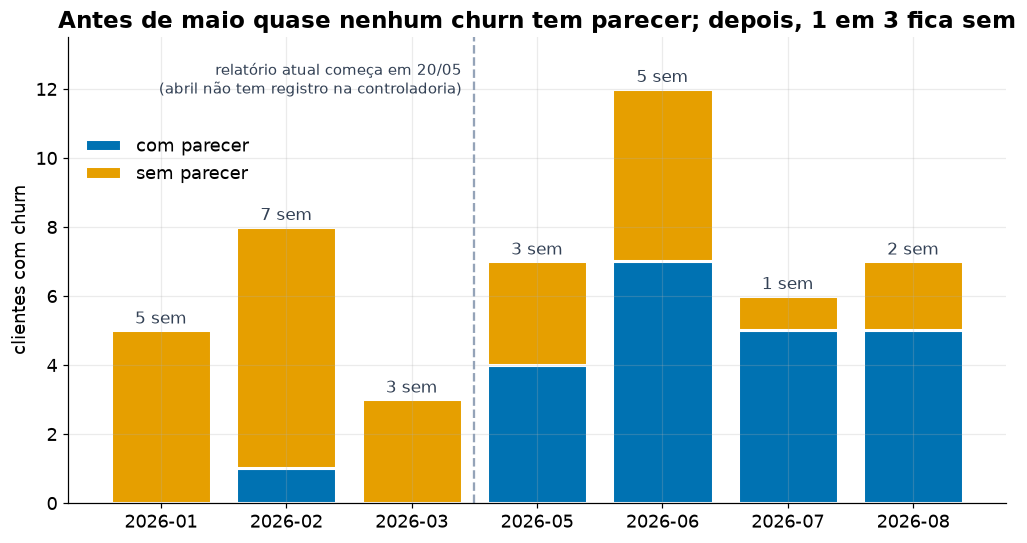

In [27]:
sem = cobertura["churns"] - cobertura["com_parecer"]
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.bar(cobertura.index, cobertura["com_parecer"], color=COR_PRIMARIA, label="com parecer", edgecolor="white", linewidth=2)
ax.bar(cobertura.index, sem, bottom=cobertura["com_parecer"], color=COR_DESTAQUE, label="sem parecer", edgecolor="white", linewidth=2)
for x, c, s in zip(cobertura.index, cobertura["com_parecer"], sem):
    ax.text(x, c + s + 0.2, f"{s} sem", ha="center", fontsize=11, color="#334155")
ax.axvline(2.5, color=COR_SECUNDARIA, linestyle="--")
ax.text(2.4, 12.8, "relatório atual começa em 20/05\n(abril não tem registro na controladoria)", fontsize=10, color="#334155", va="top", ha="right")
ax.set(title="Antes de maio quase nenhum churn tem parecer; depois, 1 em 3 fica sem", ylabel="clientes com churn", ylim=(0, 13.5))
ax.legend(frameon=False, loc="upper left", bbox_to_anchor=(0, 0.82))
plt.show()

**Resultado:** a imagem mostra o mesmo corte das contagens. Janeiro a março é quase todo laranja (antes do relatório atual). De maio em diante o azul domina, mas todo mês ainda sobra churn sem parecer.

## O que cada lado precisa fazer?
Montamos as abas da planilha de pendências: churn sem parecer (para o CS escrever), parecer incompleto (para o CS completar), parecer que não está na controladoria (para levar à controladoria) e divergências (para as duas áreas acertarem juntas). A planilha é gravada no fim do notebook, depois do cruzamento com o formulário antigo.

In [28]:
time_cs = ["AMANDA CRISTINA DA SILVA SANTOS", "ANDREZZA CAMARGO PEREIRA PERRONI", "ANA FLAVIA MOREIRA ROCHA", "RAMONA GOMES DE BRITO", "GIOVANNA ALICE FERREIRA DA COSTA"]
aba_sem_parecer = faltando.merge(churn_cli[["cod", "grupo_pendencia"]], on="cod").assign(
    competencia=lambda t: t["competencia"].dt.strftime("%m/%Y"),
    mrr_perdido=lambda t: -t["mrr_perdido"],
    csm_na_carteira=lambda t: t["csm"].fillna("sem CSM na carteira"),
    csm_no_time_atual=lambda t: t["csm"].isin(time_cs).map({True: "sim", False: "não: redistribuir"}),
)[["grupo_pendencia", "cod", "cliente", "competencia", "produtos", "mrr_perdido", "motivo_ctrl", "csm_na_carteira", "csm_no_time_atual"]].sort_values(["grupo_pendencia", "mrr_perdido"], ascending=[True, False])
aba_sem_parecer["csm_no_time_atual"].value_counts().to_frame()

,count
csm_no_time_atual,
não: redistribuir,17
sim,9


In [29]:
pd.crosstab(aba_sem_parecer["csm_na_carteira"], aba_sem_parecer["grupo_pendencia"], margins=True, margins_name="total")

grupo_pendencia,antes do relatório atual (20/05),depois do relatório atual (20/05),total
csm_na_carteira,,,
AMANDA CRISTINA DA SILVA SANTOS,2,2,4
ANDREZZA CAMARGO PEREIRA PERRONI,1,1,2
DYENIFER DA SILVA SOARES MANFROI,1,0,1
GIOVANNA ALICE FERREIRA DA COSTA,1,0,1
ISABELLA CLARINDO PAULINO,3,3,6
LUCAS LEVI PARANAGUA PINHEIRO,1,1,2
RAMONA GOMES DE BRITO,2,0,2
sem CSM na carteira,4,4,8
total,15,11,26


**Resultado:** **17 dos 26 churns sem parecer não têm um responsável no time de CS atual**: 8 estão sem CSM na carteira e 9 estão com pessoas que já não estão no CS. Então cobrar do CSM da carteira não resolve sozinho. Antes de pedir os pareceres, alguém precisa redistribuir esses 17 clientes. Os 9 que já têm dono no time podem ser cobrados direto.

Montamos as outras três abas.

In [30]:
aba_incompleto = cs.loc[cs["qtd_lacunas"] > 0, ["cod", "Cliente", "data_solicitacao", "Criado por", "qtd_lacunas", "lacunas", "Sistema migração", "Motivo churn cliente", "Motivo churn cliente outro"]].sort_values("qtd_lacunas", ascending=False)
aba_incompleto["data_solicitacao"] = aba_incompleto["data_solicitacao"].dt.strftime("%d/%m/%Y")
leitura_fora = {"SUSPENSO": "suspenso: decidir se cancela ou se foi retido", "CANCELADO": "cancelado: conferir se entra na competência de setembro"}
aba_fora_ctrl = sem_par[["cod", "Cliente", "data_solicitacao", "Tipo cancelamento", "Produtos cancelados", "MMR", "Criado por"]].assign(situacao_hoje=sem_par["cod"].map(situacao)).sort_values("data_solicitacao")
aba_fora_ctrl["o_que_fazer"] = aba_fora_ctrl["situacao_hoje"].map(leitura_fora)
aba_fora_ctrl.loc[aba_fora_ctrl["Cliente"].str.startswith("LUCIVAL"), "o_que_fazer"] = "cancelado desde maio e ausente em todos os meses: confirmar lançamento com a controladoria"
aba_fora_ctrl["data_solicitacao"] = aba_fora_ctrl["data_solicitacao"].dt.strftime("%d/%m/%Y")
aba_fora_ctrl[["Cliente", "situacao_hoje", "o_que_fazer"]]

,Cliente,situacao_hoje,o_que_fazer
27,AUGUSTO CESAR ANDRADE MAIA,SUSPENSO,suspenso: decidir se cancela ou se foi retido
17,LUCIVAL PORTILHO ARANTES IE 29.474.545-9,CANCELADO,cancelado desde maio e ausente em todos os meses: confir...
13,AGRO ALIANCA LTDA,SUSPENSO,suspenso: decidir se cancela ou se foi retido
12,IVAN ALVES SILVA,SUSPENSO,suspenso: decidir se cancela ou se foi retido
9,GEMIRO CARAFINI IE: 11.106.270-5,SUSPENSO,suspenso: decidir se cancela ou se foi retido
3,FERNANDO VIEIRA PERES,CANCELADO,cancelado: conferir se entra na competência de setembro
0,LISEU JOSE SCHERER - IE.13.260.772-7,CANCELADO,cancelado: conferir se entra na competência de setembro
1,ARLINDO FIORAVANTE CAETANO BELLINCANTA IE: 13.388.304-3,CANCELADO,cancelado: conferir se entra na competência de setembro


In [31]:
div = []
for _, r in ambos.iterrows():
    base = {"cod": r["cod"], "cliente": r["Cliente"], "csm_parecer": r["Criado por"]}
    if (r["Tipo cancelamento"] == "Parcial") != (r["tipo_ctrl"] == "Downsell") or r["Produtos cancelados"] == "BPO FINANCEIRO":
        div.append({**base, "divergencia": "tipo ou produto", "no_parecer": f'{r["Tipo cancelamento"]}: {r["Produtos cancelados"]}', "na_controladoria": f'{r["tipo_ctrl"]}: {r["produtos_ctrl"]}'})
    if abs(r["dif_%"]) > 5:
        div.append({**base, "divergencia": "valor", "no_parecer": reais(r["MMR"]), "na_controladoria": reais(-r["mrr_ctrl"])})
    if r["motivo_contraditorio"] and r["Motivo churn interno"] == "Confirma o motivo pontuado pelo cliente":
        div.append({**base, "divergencia": "motivo", "no_parecer": r["Motivo churn cliente"], "na_controladoria": r["motivo_ctrl"].strip()})
    if r["meses_ate_competencia"] > 2:
        div.append({**base, "divergencia": "prazo", "no_parecer": "pedido em " + r["data_solicitacao"].strftime("%d/%m/%Y"), "na_controladoria": "competência " + r["competencia"].strftime("%m/%Y")})
aba_divergencias = pd.DataFrame(div)
aba_divergencias["divergencia"].value_counts().to_frame()

,count
divergencia,
prazo,4
motivo,2
tipo ou produto,2
valor,2


In [32]:
abas = {
    "Churn sem parecer": aba_sem_parecer.rename(columns={"grupo_pendencia": "situação", "cod": "código", "competencia": "competência", "mrr_perdido": "MRR perdido", "motivo_ctrl": "motivo na controladoria", "csm_na_carteira": "CSM na carteira", "csm_no_time_atual": "CSM no time atual?"}),
    "Parecer incompleto": aba_incompleto.rename(columns={"cod": "código", "data_solicitacao": "data do pedido", "qtd_lacunas": "qtd de lacunas"}),
    "Parecer fora da controladoria": aba_fora_ctrl.rename(columns={"cod": "código", "data_solicitacao": "data do pedido", "MMR": "MRR", "situacao_hoje": "situação na carteira", "o_que_fazer": "o que fazer"}),
    "Divergências": aba_divergencias.rename(columns={"cod": "código", "csm_parecer": "CSM do parecer", "divergencia": "divergência", "no_parecer": "no parecer", "na_controladoria": "na controladoria"}),
}
{nome: len(t) for nome, t in abas.items()}

{'Churn sem parecer': 26,
 'Parecer incompleto': 24,
 'Parecer fora da controladoria': 8,
 'Divergências': 10}

## Os churns sem parecer estão no formulário antigo?
Antes do relatório atual, o CS preenchia um formulário (exportado em `Formulário de Churn - 2026.xlsx` e `Formulário de Churn - 2025  e 2024.xlsx`). Se o parecer de algum dos 26 faltantes estiver lá, ele não precisa ser escrito de novo: basta migrar para o relatório atual.

In [33]:
form = pd.concat([
    pd.read_excel("Formulário de Churn - 2026.xlsx").assign(arquivo="Formulário 2026"),
    pd.read_excel("Formulário de Churn - 2025  e 2024.xlsx").rename(columns={"Id": "ID"}).assign(arquivo="Formulário 2025 e 2024"),
], ignore_index=True)
form.shape, form["arquivo"].value_counts().to_dict()

((87, 27), {'Formulário 2025 e 2024': 79, 'Formulário 2026': 8})

In [34]:
form[["arquivo", "Código do cliente no SD", "Grupo Econômico (código)", "Nome do Cliente", "Data da Solicitação"]].sample(5, random_state=3)

,arquivo,Código do cliente no SD,Grupo Econômico (código),Nome do Cliente,Data da Solicitação
62,Formulário 2025 e 2024,1194947,30000817,MR TECNOLOGIA EM COLHEITAS,2025-09-30
75,Formulário 2025 e 2024,G-30000742,30000742,LUCIVAL PORTILHO ARANTES,2025-10-22
9,Formulário 2025 e 2024,G-30000205,30000205,PROCER AGRICOLA - CRICIUMA-SC,2024-06-19
45,Formulário 2025 e 2024,30000699,30000699,VALDECIR ANDRE KACZMAREK,2025-08-08
34,Formulário 2025 e 2024,30015883,30000784,SANTOS E SANTOS AGRONEGOCIO E TRANSPORTES LTDA,2025-06-23


## As duas exportações têm respostas repetidas?
As 8 respostas de 2026 começam no mesmo dia em que o arquivo de 2025 e 2024 termina. Conferimos se há resposta igual nos dois arquivos (mesma hora de início e mesmo cliente).

In [35]:
chave = ["Hora de início", "Nome do Cliente"]
dup = form[form.duplicated(chave, keep=False)].sort_values(chave)
len(dup), dup.groupby(chave)["arquivo"].agg(list).head(3)

(12,
 Hora de início       Nome do Cliente                    
 2026-04-27 08:38:21  ELIANA GASPARINI TESTA IE 111876893    [Formulário 2026, Formulário 2025 e 2024]
 2026-04-27 09:03:14  ADEMIR JOSE COMPARIM                   [Formulário 2026, Formulário 2025 e 2024]
 2026-04-27 09:16:17  CARLOS FERNANDO DA SILVEIRA BUENO      [Formulário 2026, Formulário 2025 e 2024]
 Name: arquivo, dtype: object)

**Resultado:** 6 respostas estão nos dois arquivos, o que é duplicidade da exportação e não dois pareceres. Ficamos com uma cópia de cada, a do arquivo de 2026.

In [36]:
form = form.drop_duplicates(chave, keep="first").reset_index(drop=True)
form.shape, form["arquivo"].value_counts().to_dict()

((81, 27), {'Formulário 2025 e 2024': 73, 'Formulário 2026': 8})

**Leitura:** 81 respostas únicas. Os códigos vêm em formatos misturados: com o prefixo "G-", com o código do grupo no lugar do código do cliente e, em alguns casos, com os dois campos trocados. Por isso a busca usa três caminhos: qualquer um dos dois códigos do formulário igual ao código do cliente; o código do grupo igual ao grupo do cliente na carteira; e o nome parecido.

In [37]:
somente_digitos = lambda s: pd.to_numeric(s.astype(str).str.replace(r"\D", "", regex=True), errors="coerce")
form["resposta"] = form["arquivo"] + " #" + form["ID"].astype(str)
form["cod_a"] = somente_digitos(form["Código do cliente no SD"])
form["cod_b"] = somente_digitos(form["Grupo Econômico (código)"])
grupo_carteira = carteira.dropna(subset=["cod"]).drop_duplicates("cod").set_index("cod")["CODI_GRUPO"]
faltantes = aba_sem_parecer[["cod", "cliente", "competencia", "produtos", "mrr_perdido", "grupo_pendencia", "csm_na_carteira"]].copy()
faltantes["grupo_carteira"] = faltantes["cod"].map(grupo_carteira)
faltantes[["cod", "cliente", "grupo_carteira"]].head(3), faltantes["grupo_carteira"].notna().sum()

(        cod                               cliente  grupo_carteira
 0  30007727           3SB PRODUTOS AGRICOLAS S.A.      30000555.0
 1  30013024  RICARDO SILVA ROCHA IE: 11.196.197-1      30000377.0
 5  30006916       CLODOVEU FRANCIOSI IE 133535746      10000663.0,
 np.int64(18))

In [38]:
def candidatos(f):
    por_codigo = form[form["cod_a"].eq(f["cod"]) | form["cod_b"].eq(f["cod"])].assign(como="código")
    por_grupo = form[form["cod_a"].eq(f["grupo_carteira"]) | form["cod_b"].eq(f["grupo_carteira"])].assign(como="grupo") if pd.notna(f["grupo_carteira"]) else form.iloc[0:0]
    notas = form["Nome do Cliente"].apply(lambda n: fuzz.token_set_ratio(n, f["cliente"]))
    por_nome = form[notas >= 85].assign(como="nome")
    return pd.concat([por_codigo, por_grupo, por_nome]).assign(cod=f["cod"], nota_nome=notas).groupby("resposta", as_index=False).agg({"cod": "first", "como": lambda s: " + ".join(sorted(set(s))), "nota_nome": "first", "arquivo": "first", "Nome do Cliente": "first", "Data da Solicitação": "first", "Produtos Cancelados": "first", "Nome": "first"})

achados = pd.concat([candidatos(f) for _, f in faltantes.iterrows()], ignore_index=True)
achados = achados.merge(faltantes[["cod", "cliente", "competencia"]], on="cod")
achados[["cliente", "Nome do Cliente", "como", "nota_nome", "Data da Solicitação", "competencia", "Produtos Cancelados"]]

,cliente,Nome do Cliente,como,nota_nome,Data da Solicitação,competencia,Produtos Cancelados
0,FLAVIO FAEDO IE 11.508.239-5,FLAVIO FAEDO,nome,100.0,2026-04-27,02/2026,MYFARM
1,ACASSIO TELES DE CASTRO,ACASSIO TELES DE CASTRO,código + nome,100.0,2025-12-11,01/2026,MYFARM
2,ADEMIR JOSE COMPARIM IE-28.523.221-5,ADEMIR JOSE COMPARIM,código + nome,100.0,2026-02-27,01/2026,MYFARM
3,RENTAX AGROSOLUCOES E SERVICOS ADMINISTRATIVOS LTDA,RENTAX AGROSOLUCOES E SERVICOS ADMINISTRATIVOS LTDA,código + grupo + nome,100.0,2026-01-12,01/2026,Myfarm
4,CARLOS FERNANDO DA SILVEIRA BUENO,CARLOS FERNANDO DA SILVEIRA BUENO,código + grupo + nome,100.0,2026-02-13,01/2026,MYFARM
5,ELIANA GASPARINI TESTA IE 111876893,ELIANA GASPARINI TESTA IE 111876893,código + grupo + nome,100.0,2026-02-04,02/2026,MYFARM
6,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,GERALDO AUGUSTO MARTINS,grupo + nome,100.0,2025-07-07,03/2026,myFarm
7,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,GERALDO AUGUSTO MARTINS,grupo + nome,100.0,2025-07-07,03/2026,MYFARM
8,LEINNER LIMA BORGES IE 11.468.592-4,LEINNER LIMA BORGES IE 11.468.592-4,código + nome,100.0,2025-12-15,02/2026,Myfarm
9,VALQUIRIA MARCELINO FERREIRA ABREU IE: 13.429.008-9,VALQUIRIA MARCELINO FERREIRA ABREU,código + nome,100.0,2026-01-02,05/2026,Agrimanager


**Primeira leitura:** 10 dos 26 clientes aparecem no formulário antigo, e o Geraldo tem duas respostas. Mas achar o nome não basta: o parecer precisa ser **do mesmo cancelamento**. Em quatro casos a data não fecha com a competência. O pedido do Stracci é de um ano antes e bateu só pelo grupo; o do Geraldo é de oito meses antes; e os do Flávio e do Ademir são posteriores à competência. Comparamos código, valor e produto com a controladoria.

In [39]:
detalhe = achados.merge(form[["resposta", "cod_a", "cod_b", "MMR (valor mensal de recorrência)", "Tipo de Cancelamento", "Hora de início", "Detalhamento sobre o histórico do cliente e motivo de cancelamento."]], on="resposta").merge(faltantes[["cod", "mrr_perdido", "produtos"]], on="cod")
detalhe["texto"] = detalhe["Detalhamento sobre o histórico do cliente e motivo de cancelamento."].str[:160]
detalhe[["cliente", "cod", "cod_a", "cod_b", "MMR (valor mensal de recorrência)", "mrr_perdido", "produtos", "Produtos Cancelados", "Data da Solicitação", "Hora de início", "competencia"]]

,cliente,cod,cod_a,cod_b,MMR (valor mensal de recorrência),mrr_perdido,produtos,Produtos Cancelados,Data da Solicitação,Hora de início,competencia
0,FLAVIO FAEDO IE 11.508.239-5,130.0,30002569,30002569,"1.201,82",1201.82,My Farm ERP,MYFARM,2026-04-27,2026-04-27 13:29:44,02/2026
1,ACASSIO TELES DE CASTRO,30017239.0,30001099,30017239,"1200,00",1200.00,My Farm ERP,MYFARM,2025-12-11,2026-04-27 09:31:29,01/2026
2,ADEMIR JOSE COMPARIM IE-28.523.221-5,30012242.0,30000815,30012242,"840,51",840.51,My Farm ERP,MYFARM,2026-02-27,2026-04-27 09:03:14,01/2026
3,RENTAX AGROSOLUCOES E SERVICOS ADMINISTRATIVOS LTDA,30016676.0,30016676,30001116,"620,27",620.27,My Farm ERP,Myfarm,2026-01-12,2026-04-27 09:42:54,01/2026
4,CARLOS FERNANDO DA SILVEIRA BUENO,30017285.0,30001104,30017285,"583,33",583.33,My Farm ERP,MYFARM,2026-02-13,2026-04-27 09:16:17,01/2026
5,ELIANA GASPARINI TESTA IE 111876893,30018091.0,30018091,30001196,"480,00",480.00,My Farm ERP,MYFARM,2026-02-04,2026-04-27 08:38:21,02/2026
6,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,30015743.0,30000809,30000809,"473,35",320.00,My Farm ERP,myFarm,2025-07-07,2025-07-31 10:10:24,03/2026
7,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,30015743.0,30000809,30000809,"473,35",320.00,My Farm ERP,MYFARM,2025-07-07,2025-08-26 08:47:19,03/2026
8,LEINNER LIMA BORGES IE 11.468.592-4,30012511.0,30012511,30000700,"302,91",302.91,My Farm ERP,Myfarm,2025-12-15,2026-04-27 08:37:36,02/2026
9,VALQUIRIA MARCELINO FERREIRA ABREU IE: 13.429.008-9,30016155.0,30016155,30000667,2110.82,2110.81,"Agrimanager ERP, Aliare Cloud - PR",Agrimanager,2026-01-02,2026-06-15 11:45:00,05/2026


In [40]:
for _, r in detalhe[detalhe["cliente"].str.contains("STRACCI|GERALDO")].iterrows():
    print(r["resposta"], "|", r["Nome do Cliente"], "| pedido", r["Data da Solicitação"].date(), "| MRR", r["MMR (valor mensal de recorrência)"], "|", r["Tipo de Cancelamento"], "\n", r["Detalhamento sobre o histórico do cliente e motivo de cancelamento."], "\n")

Formulário 2025 e 2024 #31 | GERALDO AUGUSTO MARTINS | pedido 2025-07-07 | MRR 473,35 | Total 
 O cliente, que atua no segmento agropecuário, com foco na produção de leite e criação de gado, utilizou a plataforma MyFarm ao longo do seu ciclo de relacionamento com a Aliare. Durante esse período, demonstrou satisfação com o suporte e os recursos oferecidos, reconhecendo que o sistema atendeu às suas necessidades em aspectos importantes da gestão. Conforme registrado em seu relato: “Gostaria de agradecer até o momento, o MyFarm nos atendeu muito bem”, o cliente demonstrou gratidão e uma visão positiva sobre a experiência de uso do ERP.

Entretanto, à medida que a operação do cliente se desenvolveu, novas demandas surgiram, especialmente relacionadas ao controle zootécnico, uma área fundamental para a gestão de propriedades voltadas à produção leiteira e pecuária de corte. Essa necessidade foi o ponto de inflexão que motivou a busca por um novo sistema. O cliente destacou que seu segmento 

**Geraldo:** as duas respostas são do mesmo pedido (07/2025). A segunda (#41) explica o valor: depois do cancelamento, o cliente ficou seis meses num contrato reduzido de `R$ 320,00`, só para consulta, e é exatamente esse contrato que sai em 03/2026. [Certo] É o mesmo cancelamento, e a resposta #41 é a mais completa para migrar.

**Stracci:** o parecer é do grupo inteiro, de 06/2025, com `R$ 2.490,52`, e o churn na controladoria é de um contrato só, de `R$ 1.040,32`, em 06/2026. Olhamos os contratos do grupo na carteira.

In [41]:
carteira[carteira["NOME_GRUPO"].astype(str).str.contains("STRACCI", case=False) | carteira["CLIENTE"].astype(str).str.contains("STRACCI", case=False)][["cod", "CLIENTE", "NOME_GRUPO", "CONTRATO", "PRODUTO", "VALOR_CONTRATO", "SITUACAO_CONTRATO", "DATA_CONTRATO"]]

,cod,CLIENTE,NOME_GRUPO,CONTRATO,PRODUTO,VALOR_CONTRATO,SITUACAO_CONTRATO,DATA_CONTRATO
238,30016543.0,LUCAS BOLOGNINI STRACCI,GRUPO STRACCI - BARREIRAS-BA,30001182.0,AGRIMANAGER ERP,1040.32,CANCELADO,2015-11-26


**Resultado:** o grupo Stracci tem um único contrato na carteira, o AgriManager de `R$ 1.040,32`, já cancelado. O parecer de 2025 fala justamente do cancelamento do AgriManager, com troca pelo Agromobi e a multa ainda em discussão. É provável que seja o mesmo cancelamento, concluído um ano depois. A diferença de valor sugere que o grupo tinha outros itens que saíram antes. [Provável] Entra na migração, mas marcado para confirmar.

Os demais batem em nome, valor (ao centavo) e produto. No Flávio, no Ademir e no Carlos Fernando, a data do pedido no formulário é posterior à competência, porque no formulário de 2026 a "data da solicitação" foi preenchida com a data em que o parecer foi escrito (27/04). [Certo] O valor e o nome confirmam que é o mesmo caso.

## Quais pareceres vamos migrar, e quais churns continuam faltando?
Escolhemos uma resposta por cliente (no Geraldo, a #41) e classificamos cada um.

In [42]:
escolha = detalhe[detalhe["resposta"] != "Formulário 2025 e 2024 #31"].copy()
escolha["status_migracao"] = "migrar"
escolha.loc[escolha["cliente"].str.contains("STRACCI"), "status_migracao"] = "migrar após confirmar (parecer do grupo de 06/2025, valor diferente)"
faltantes["situacao_formulario"] = faltantes["cod"].map(escolha.set_index("cod")["status_migracao"]).fillna("continua faltando")
faltantes["situacao_formulario"].value_counts().to_frame()

,count
situacao_formulario,
continua faltando,16
migrar,9
"migrar após confirmar (parecer do grupo de 06/2025, valor diferente)",1


**Resultado:** 10 dos 26 churns sem parecer já tinham parecer no formulário antigo (9 certos e o Stracci a confirmar). Os **16 restantes continuam faltando**. O formulário antigo cobre sobretudo o começo do ano, e isso muda o retrato: onde está o que ainda falta?

In [43]:
ainda_falta = faltantes[faltantes["situacao_formulario"] == "continua faltando"].merge(aba_sem_parecer[["cod", "csm_no_time_atual"]], on="cod")
resumo_falta = ainda_falta.groupby("grupo_pendencia").agg(clientes=("cod", "size"), mrr_perdido=("mrr_perdido", "sum"), sem_dono_no_time=("csm_no_time_atual", lambda s: (s != "sim").sum()))
resumo_falta.assign(mrr_perdido=resumo_falta["mrr_perdido"].map(reais))

,clientes,mrr_perdido,sem_dono_no_time
grupo_pendencia,,,
antes do relatório atual (20/05),7,"R$ 14.897,64",2
depois do relatório atual (20/05),9,"R$ 11.700,83",6


**Resultado:** o que ainda falta mudou de perfil. Antes eram 15 casos anteriores a maio e 11 posteriores; agora são **7 anteriores e 9 posteriores ao relatório atual**. O formulário antigo resolveu a maior parte do começo do ano. O que sobra é sobretudo **falha de processo recente**, e 6 desses 9 casos estão sem dono no time atual. Nesses meses já existia algum instrumento de parecer, então nenhum dos 16 é "trabalho retroativo sem culpa". [Certo]

Os 16 que continuam faltando, com o CSM da carteira:

In [44]:
ainda_falta[["grupo_pendencia", "cliente", "competencia", "produtos", "mrr_perdido", "csm_na_carteira", "csm_no_time_atual"]].sort_values(["grupo_pendencia", "mrr_perdido"], ascending=[False, False])

,grupo_pendencia,cliente,competencia,produtos,mrr_perdido,csm_na_carteira,csm_no_time_atual
7,depois do relatório atual (20/05),LUIS HENRIQUE PAZINI E OUTRO - IE - 133440532,05/2026,My Farm ERP,2775.5500,sem CSM na carteira,não: redistribuir
8,depois do relatório atual (20/05),ZORZETTO ASSES. E CONSULTORIA AGRONOMICA LTDA.,06/2026,Agrimanager ERP,2243.4600,LUCAS LEVI PARANAGUA PINHEIRO,não: redistribuir
9,depois do relatório atual (20/05),CAPIVARY AGRO PASTORIL - GOIANIA-GO,08/2026,Agrimanager ERP,1847.8200,ISABELLA CLARINDO PAULINO,não: redistribuir
10,depois do relatório atual (20/05),ANDRE LUIZ COELHO GUILHERME,05/2026,My Farm ERP,1073.2900,ISABELLA CLARINDO PAULINO,não: redistribuir
11,depois do relatório atual (20/05),THIAGO DE ALMEIDA,06/2026,My Farm ERP,1067.5800,ANDREZZA CAMARGO PEREIRA PERRONI,sim
12,depois do relatório atual (20/05),EDUARDO ZORZI - I.E. 13.322.258-6,07/2026,Vistra BI - PR,839.3300,AMANDA CRISTINA DA SILVA SANTOS,sim
13,depois do relatório atual (20/05),VALDIR FREIER IE 00132823500,06/2026,My Farm ERP,772.9000,sem CSM na carteira,não: redistribuir
14,depois do relatório atual (20/05),GUILHERME DE ARAUJO PREDIGER,06/2026,My Farm ERP,621.2600,sem CSM na carteira,não: redistribuir
15,depois do relatório atual (20/05),AGROPECUARIA ALVORADA - BELA VISTA DE GOIAS-GO,08/2026,Agrimanager ERP,459.6400,AMANDA CRISTINA DA SILVA SANTOS,sim
0,antes do relatório atual (20/05),3SB PRODUTOS AGRICOLAS S.A.,02/2026,Agrimanager ERP,4170.4600,DYENIFER DA SILVA SOARES MANFROI,não: redistribuir


**Leitura:** os 7 que faltam de antes de maio são todos AgriManager, Algodoeira, Aliare Cloud ou Vistra BI, e nenhum é myFarm. Nove dos 10 achados no formulário antigo eram myFarm. [Provável] O formulário antigo era usado sobretudo na carteira myFarm, e produtos complementares (Vistra BI, Aliare Cloud) não passavam pelo parecer. Com 7 casos, é um indício, não uma regra.

## Como fica o parecer migrado no formato do relatório atual?
Cada resposta do formulário antigo é convertida para as colunas do relatório atual, com o código de cliente da controladoria (que é o certo), para o CS copiar sem retrabalho.

In [45]:
def para_numero(v):
    return v if isinstance(v, (int, float)) else float(str(v).replace(".", "").replace(",", ".")) if "," in str(v) else float(v)

def para_data(v):
    if isinstance(v, (int, float)) and not pd.isna(v):
        return pd.Timestamp("1899-12-30") + pd.Timedelta(days=v)
    return pd.to_datetime(v, errors="coerce")

In [46]:
m = escolha.merge(form, on="resposta", suffixes=("", "_f"))
aba_migrar = pd.DataFrame({
    "status da migração": m["status_migracao"],
    "origem": m["resposta"],
    "preenchido por": m["Nome_f"],
    "competência na controladoria": m["competencia"],
    "Data solicitação": m["Data da Solicitação_f"].dt.strftime("%d/%m/%Y"),
    "Código SD": m["cod"].astype(int),
    "Cliente": m["cliente"],
    "Cidade": m["Cidade"], "UF": m["Estado"],
    "Grupo econômico": m["Grupo Econômico (código)"],
    "MMR": m["MMR (valor mensal de recorrência)"].apply(para_numero),
    "Curva": m["Curva do Cliente"], "Tamanho cliente": m["Tamanho do cliente"],
    "Tipo cancelamento": m["Tipo de Cancelamento"], "Produtos cancelados": m["Produtos Cancelados_f"],
    "Motivo churn cliente": m["Motivo de churn informado pelo cliente"], "Cliente engajado": m["Cliente Engajado"],
    "Motivo churn interno": m["Motivo de churn levantado internamente"], "Sistema migração": m["Para qual sistema o cliente\xa0está migrando?\xa0"],
    "NPS": m["Nota do último NPS do cliente?"],
    "Data assinatura contrato": m["Data de Assinatura do contrato"].apply(para_data).dt.strftime("%d/%m/%Y"),
    "Data última RTR": m["Data última agenda de RTR?"].apply(para_data).dt.strftime("%d/%m/%Y"),
    "Histórico motivo cancelamento": m["Detalhamento sobre o histórico do cliente e motivo de cancelamento._f"],
    "Detalhamento abordagem": m["Detalhamento das abordagem e contornos feitos com o cliente."],
})
aba_migrar[["Cliente", "MMR", "Tipo cancelamento", "Motivo churn cliente", "Sistema migração", "NPS", "Data assinatura contrato", "Data última RTR"]]

,Cliente,MMR,Tipo cancelamento,Motivo churn cliente,Sistema migração,NPS,Data assinatura contrato,Data última RTR
0,FLAVIO FAEDO IE 11.508.239-5,1201.82,Total,Erros Recorrentes / Instabilidade,AEGRO,03,31/08/2021,21/10/2025
1,ACASSIO TELES DE CASTRO,1200.00,Total,Falta de Personalização Solicitado pelo Cliente,NÃO TEMOS ESSA INFORMAÇÃO,NÃO HÁ PESQUISA RESPONDIDA,06/01/2025,11/12/2025
2,ADEMIR JOSE COMPARIM IE-28.523.221-5,840.51,Total,Falta de Funcionalidades Essenciais,NÃO TEMOS CONHECIMENTO,SEM PESQUISA RESPONDIDA,29/12/2021,27/02/2026
3,RENTAX AGROSOLUCOES E SERVICOS ADMINISTRATIVOS LTDA,620.27,Total,Encerramento das Atividades da empresa,Empresa encerrada,8,12/09/2025,03/11/2025
4,CARLOS FERNANDO DA SILVEIRA BUENO,583.33,Total,Falta de Personalização Solicitado pelo Cliente,NÃO TEMOS CONHECIMENTO,10,16/01/2025,06/02/2026
5,ELIANA GASPARINI TESTA IE 111876893,480.00,Total,Falta de Funcionalidades Essenciais,Desenvolveu o próprio sistema,10,22/08/2025,04/02/2026
6,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,473.35,Total,Falta de Funcionalidades Essenciais,IDEAGRI,16/07/2025,06/12/2023,11/07/2025
7,LEINNER LIMA BORGES IE 11.468.592-4,302.91,Total,Erros Recorrentes / Instabilidade,Não informado,Não possuem.,03/03/2022,12/11/2025
8,VALQUIRIA MARCELINO FERREIRA ABREU IE: 13.429.008-9,2110.82,Total,Todas as solicitações serem por ticket,NÃO TEMOS CONHECIMENTO,10,06/04/2026,NaN
9,LUCAS BOLOGNINI STRACCI,2490.52,Total,Diminuição de custos,Agromobi,10,26/11/2015,18/04/2025


In [47]:
form.loc[form["resposta"].isin(m.loc[m["cliente"].str.contains("VALQUIRIA|GERALDO"), "resposta"]), ["resposta", "Hora de início", "Data de Assinatura do contrato", "Nota do último NPS do cliente?", "Data última agenda de RTR?", "Motivo de churn informado pelo cliente"]].T

,6,48
resposta,Formulário 2026 #80,Formulário 2025 e 2024 #41
Hora de início,2026-06-15 11:45:00,2025-08-26 08:47:19
Data de Assinatura do contrato,2026-04-06 00:00:00,45266
Nota do último NPS do cliente?,10,16/07/2025
Data última agenda de RTR?,NÃO FOI LOCALIZADO,2025-07-11 00:00:00
Motivo de churn informado pelo cliente,Todas as solicitações serem por ticket,Falta de Funcionalidades Essenciais


Vale conferir a data de assinatura do formulário contra a data do contrato na carteira, para todos os migrados.

In [48]:
data_carteira = carteira.dropna(subset=["cod"]).groupby("cod")["DATA_CONTRATO"].min()
aba_migrar.assign(carteira=pd.to_datetime(aba_migrar["Código SD"].map(data_carteira)).dt.strftime("%d/%m/%Y"))[["Cliente", "Data assinatura contrato", "carteira"]]

,Cliente,Data assinatura contrato,carteira
0,FLAVIO FAEDO IE 11.508.239-5,31/08/2021,31/08/2021
1,ACASSIO TELES DE CASTRO,06/01/2025,06/01/2025
2,ADEMIR JOSE COMPARIM IE-28.523.221-5,29/12/2021,29/12/2021
3,RENTAX AGROSOLUCOES E SERVICOS ADMINISTRATIVOS LTDA,12/09/2025,07/08/2024
4,CARLOS FERNANDO DA SILVEIRA BUENO,16/01/2025,17/01/2025
5,ELIANA GASPARINI TESTA IE 111876893,22/08/2025,22/08/2025
6,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,06/12/2023,06/12/2023
7,LEINNER LIMA BORGES IE 11.468.592-4,03/03/2022,03/03/2022
8,VALQUIRIA MARCELINO FERREIRA ABREU IE: 13.429.008-9,06/04/2026,06/04/2024
9,LUCAS BOLOGNINI STRACCI,26/11/2015,26/11/2015


**Resultado:** 7 dos 10 batem com a carteira (o Carlos Fernando difere em um dia). A **Valquíria** tem o ano trocado (2026 no lugar de 2024), e a **Rentax** tem uma data que não bate com a carteira. Junto com o NPS do Geraldo (uma data no lugar da nota) e o sistema de destino não informado em metade dos casos, isso vira uma coluna de pontos a corrigir no momento da migração.

In [49]:
destino_vazio_form = aba_migrar["Sistema migração"].str.upper().str.contains("NÃO TEMOS|NÃO INFORMADO")
ajustes = {
    "VALQUIRIA": "data de assinatura: carteira diz 06/04/2024; motivo fora da lista padrão (classificar); última RTR não localizada",
    "RENTAX": "data de assinatura: carteira diz 07/08/2024",
    "GERALDO": "campo NPS tem uma data (16/07/2025): buscar a nota; MMR do formulário é o valor cheio (a controladoria lançou os R$ 320 do contrato de consulta)",
    "STRACCI": "confirmar se é o mesmo cancelamento: parecer do grupo em 06/2025 com R$ 2.490,52; controladoria lançou R$ 1.040,32 em 06/2026",
}
aba_migrar["corrigir antes de migrar"] = aba_migrar["Cliente"].apply(lambda n: next((v for k, v in ajustes.items() if k in n), ""))
aba_migrar.loc[destino_vazio_form, "corrigir antes de migrar"] = (aba_migrar.loc[destino_vazio_form, "corrigir antes de migrar"] + "; sistema de destino não informado").str.lstrip("; ")
aba_migrar[["Cliente", "corrigir antes de migrar"]]

,Cliente,corrigir antes de migrar
0,FLAVIO FAEDO IE 11.508.239-5,
1,ACASSIO TELES DE CASTRO,sistema de destino não informado
2,ADEMIR JOSE COMPARIM IE-28.523.221-5,sistema de destino não informado
3,RENTAX AGROSOLUCOES E SERVICOS ADMINISTRATIVOS LTDA,data de assinatura: carteira diz 07/08/2024
4,CARLOS FERNANDO DA SILVEIRA BUENO,sistema de destino não informado
5,ELIANA GASPARINI TESTA IE 111876893,
6,GERALDO AUGUSTO MARTINS TEIXEIRA IE 37260520019,campo NPS tem uma data (16/07/2025): buscar a nota; MMR ...
7,LEINNER LIMA BORGES IE 11.468.592-4,sistema de destino não informado
8,VALQUIRIA MARCELINO FERREIRA ABREU IE: 13.429.008-9,data de assinatura: carteira diz 06/04/2024; motivo fora...
9,LUCAS BOLOGNINI STRACCI,confirmar se é o mesmo cancelamento: parecer do grupo em...


## E os 8 pareceres que não estão na controladoria, têm histórico no formulário antigo?
O Lucival aparece no formulário de 2025. Se o cancelamento já tinha sido pedido em 2025, o churn pode ter sido lançado naquele ano, fora da planilha de 2026.

In [50]:
fora = sem_par[["cod", "Cliente", "data_solicitacao", "MMR"]].rename(columns={"Cliente": "cliente"}).assign(grupo_carteira=sem_par["cod"].map(grupo_carteira))
hist = pd.concat([candidatos(f) for _, f in fora.iterrows()], ignore_index=True).merge(fora[["cod", "cliente", "data_solicitacao"]], on="cod")
hist[["cliente", "Nome do Cliente", "como", "Data da Solicitação", "data_solicitacao", "Produtos Cancelados"]]

,cliente,Nome do Cliente,como,Data da Solicitação,data_solicitacao,Produtos Cancelados
0,LUCIVAL PORTILHO ARANTES IE 29.474.545-9,LUCIVAL PORTILHO ARANTES,grupo + nome,2025-10-22,2026-05-23,MYFARM


**Resultado:** só o Lucival tem histórico no formulário antigo, e é de **outro cancelamento**. Em 10/2025 ele cancelou o **myFarm**, e o pedido de 05/2026 é do **AgriManager com Aliare Cloud**. Então o formulário não explica a ausência dele na controladoria de 2026. Continua sendo o caso a levar à controladoria. [Provável]

## Planilha de pendências atualizada
A aba "Churn sem parecer" fica só com os 16 que continuam faltando, e entra a aba "Migrar do formulário antigo" com os 10 pareceres no formato do relatório atual.

In [51]:
abas["Churn sem parecer"] = abas["Churn sem parecer"][abas["Churn sem parecer"]["código"].isin(ainda_falta["cod"])]
abas = {"Churn sem parecer": abas["Churn sem parecer"], "Migrar do formulário antigo": aba_migrar, **{k: v for k, v in abas.items() if k != "Churn sem parecer"}}
saida = "pendencias-parecer-churn-2026-09-30.xlsx"
with pd.ExcelWriter(saida, engine="openpyxl") as w:
    for nome, t in abas.items():
        t.to_excel(w, sheet_name=nome, index=False)
        ws = w.sheets[nome]
        ws.freeze_panes = "A2"
        for col in ws.columns:
            ws.column_dimensions[col[0].column_letter].width = min(60, max(12, max(len(str(c.value or "")) for c in col) + 2))
            if str(col[0].value) in ("MRR", "MMR", "MRR perdido"):
                for c in col[1:]:
                    c.number_format = '"R$" #,##0.00'
{nome: len(t) for nome, t in abas.items()}

{'Churn sem parecer': 16,
 'Migrar do formulário antigo': 10,
 'Parecer incompleto': 24,
 'Parecer fora da controladoria': 8,
 'Divergências': 10}

## Conclusões

**Base:** 48 clientes com churn na controladoria (janeiro a agosto de 2026, sem registro em abril), 31 pareceres no relatório de churn atual (em uso desde 20/05/2026) e 81 respostas únicas no formulário antigo (2024 a 2026). Downsell (13 clientes) ficou fora da cobrança de parecer.

**Cobertura de parecer dos 48 churns**
- **22** têm parecer no relatório atual.
- **10** têm parecer só no formulário antigo e vão para a migração: 9 confirmados por nome, valor e produto, e o **Stracci a confirmar** (o parecer é do grupo, de 06/2025, com valor diferente do lançado). [Certo nos 9, Provável no Stracci]
- **16 continuam sem parecer nenhum** (`R$ 26,6 mil` de MRR perdido). [Certo]
  - **9 são de maio em diante**, com o relatório atual já em uso: é falha de processo, e 6 deles estão sem dono no time atual.
  - **7 são de janeiro a março** e são todos AgriManager, Algodoeira, Aliare Cloud ou Vistra BI. Nove dos 10 achados no formulário antigo eram myFarm. [Provável] O parecer não era feito na carteira AgriManager nem nos produtos complementares.
  - **8 dos 16 não têm dono no time de CS atual** (sem CSM na carteira ou com CSM que saiu do CS). É preciso redistribuir antes de cobrar.

**Migração do formulário antigo:** os 10 já estão no formato do relatório atual, com o código de cliente da controladoria. Antes de migrar, é preciso corrigir: o sistema de destino não informado em 5 casos, a data de assinatura da Valquíria (ano 2026 no lugar de 2024) e da Rentax, o NPS do Geraldo (o campo tem uma data) e o motivo da Valquíria, que está fora da lista padrão. A exportação do formulário trazia 6 respostas repetidas entre os dois arquivos, e elas foram descartadas.

**O que o relatório atual ainda precisa melhorar:** dos 31 pareceres, só 7 estão completos. Metade não diz para onde o cliente foi, um terço usa "Outro" como motivo, e a lista de motivos não oferece opções que aparecem nos textos (troca pelo sistema do contador, uso só para nota fiscal, dificuldade financeira). [Provável] O Bruno Sanches Toro não cita o Aliare Cloud lançado pela controladoria. [Certo]

**O que falta na controladoria**
- **Ademir e Carlos Fernando** estão como "motivo não identificado, histórico de CS não localizado", mas o parecer existe no formulário antigo. A controladoria pode atualizar o motivo. [Certo]
- **8 pareceres não aparecem em nenhum mês.** 4 são de clientes suspensos, o que é esperado, porque a controladoria só conta o cancelamento formal. Mas os pedidos são de abril a junho e seguem parados. 3 pediram entre agosto e setembro e devem entrar em setembro. [Provável]
- **Lucival** continua sem explicação: o formulário antigo registra outro cancelamento (o myFarm, em 10/2025), e o pedido de 05/2026 é do AgriManager com Aliare Cloud (`R$ 5,9 mil`), que não aparece em nenhum mês. [Provável]
- **Abril não tem nenhum lançamento.** [Suposição: com 7 a 12 churns nos meses vizinhos, zero em abril é improvável]

**Divergências nos 23 casos que aparecem nas duas bases:** tipo e valor batem em quase todos. As exceções são Leonardo Luiz Oss (BPO parcial de `R$ 1,4 mil` no parecer; downsell de `R$ 4,2 mil` no myFarm na controladoria) e Estrela da Manhã (parcial no parecer, churn na controladoria). Só Fravale e Edgar Gomes têm motivo contraditório. Quatro casos levaram 3 a 4 meses entre o pedido e a competência do churn.

**Arquivo gerado:** `pendencias-parecer-churn-2026-09-30.xlsx`, com as abas Churn sem parecer (16), Migrar do formulário antigo (10), Parecer incompleto, Parecer fora da controladoria e Divergências.